# 🧠 Algoritmo de Simon

O **Algoritmo de Simon** é um marco fundamental na teoria da computação quântica. Proposto por Daniel Simon em 1994, ele foi o primeiro algoritmo a demonstrar uma **vantagem exponencial provável** de um computador quântico sobre qualquer computador clássico na resolução de um problema específico. Ele foi a principal base e inspiração para o famoso Algoritmo de Shor.

## 🎯 O Problema de Simon

Imagine que temos uma função "caixa preta" (oráculo) $f$ que recebe uma string de $n$ bits e retorna outra string de $n$ bits: $f: \{0,1\}^n \rightarrow \{0,1\}^n$.

Temos uma promessa sobre esta função: ela esconde uma string secreta $s$. A função mapeia duas entradas distintas para a mesma saída se, e somente se, essas entradas diferirem exatamente por uma operação XOR bit a bit ($\oplus$) com $s$. Matematicamente:

$$f(x) = f(y) \iff y = x \oplus s$$

O objetivo do problema é **encontrar a string secreta $s$**.

## 🚀 A Vantagem Quântica

*   **Abordagem Clássica:** Para descobrir $s$ com alta probabilidade de acerto, um algoritmo clássico precisaria consultar a função um número de vezes proporcional a $O(2^{n/2})$ (devido à lógica do Paradoxo do Aniversário).
*   **Abordagem Quântica:** O Algoritmo de Simon consegue encontrar a string secreta $s$ fazendo um número de consultas linear, ou seja, $O(n)$ vezes.

## ⚙️ Como Funciona (Resumo do Circuito)

1.  **Superposição:** Portas Hadamard são aplicadas em $n$ qubits (inicializados em $|0\rangle$), criando uma superposição uniforme de todas as entradas possíveis simultaneamente.
2.  **Oráculo:** A função $f$ é avaliada de forma quântica (o Oráculo de Simon), emaranhando o estado de entrada com os registradores de saída.
3.  **Interferência:** Aplica-se portas Hadamard novamente nos registradores de entrada. Isso gera uma interferência que "apaga" as probabilidades de medir certos estados.
4.  **Medição:** Ao medir os qubits, o resultado será sempre uma string $z$ que possui um produto interno módulo 2 igual a zero com a nossa string secreta $s$. Ou seja:
    $$z \cdot s \equiv 0 \pmod 2$$
5.  **Pós-processamento Clássico:** O circuito quântico é executado múltiplas vezes (aproximadamente $n$ vezes) para obter um sistema de equações lineares independentes. Por fim, um computador clássico resolve esse sistema (usando eliminação de Gauss, por exemplo) para revelar o valor de $s$.

In [2]:
#Bibliotecas 
import pennylane as qml 
from pennylane import numpy as np 
import matplotlib.pyplot as plt

In [3]:
#Chave secreta e definir os Qubits
secret_s = "011"
n = len(secret_s)                                                              
dev = qml.device("default.qubit", wires = 6, shots = 1000)

In [4]:
#Modelagem do Circuito
@qml.qnode(dev)
def circuito_simon():
    qml.Hadamard(wires=0)
    qml.Hadamard(wires=1)
    qml.Hadamard(wires=2)
    qml.Barrier([0,5])
    qml.CNOT([0,3])
    qml.CNOT([1,4])
    qml.CNOT([2,5])
    qml.Barrier([0,5])
    
    qml.CNOT([1,4])
    qml.CNOT([1,5])
    
    qml.CNOT([0,5])
    
    qml.Barrier([0,5])
    qml.measure(3)
    qml.measure(4)
    qml.measure(5)
    qml.Barrier([0,5])
    qml.Hadamard(wires=0)
    qml.Hadamard(wires=1)
    qml.Hadamard(wires=2)
    return qml.counts(wires=[0,1,2])


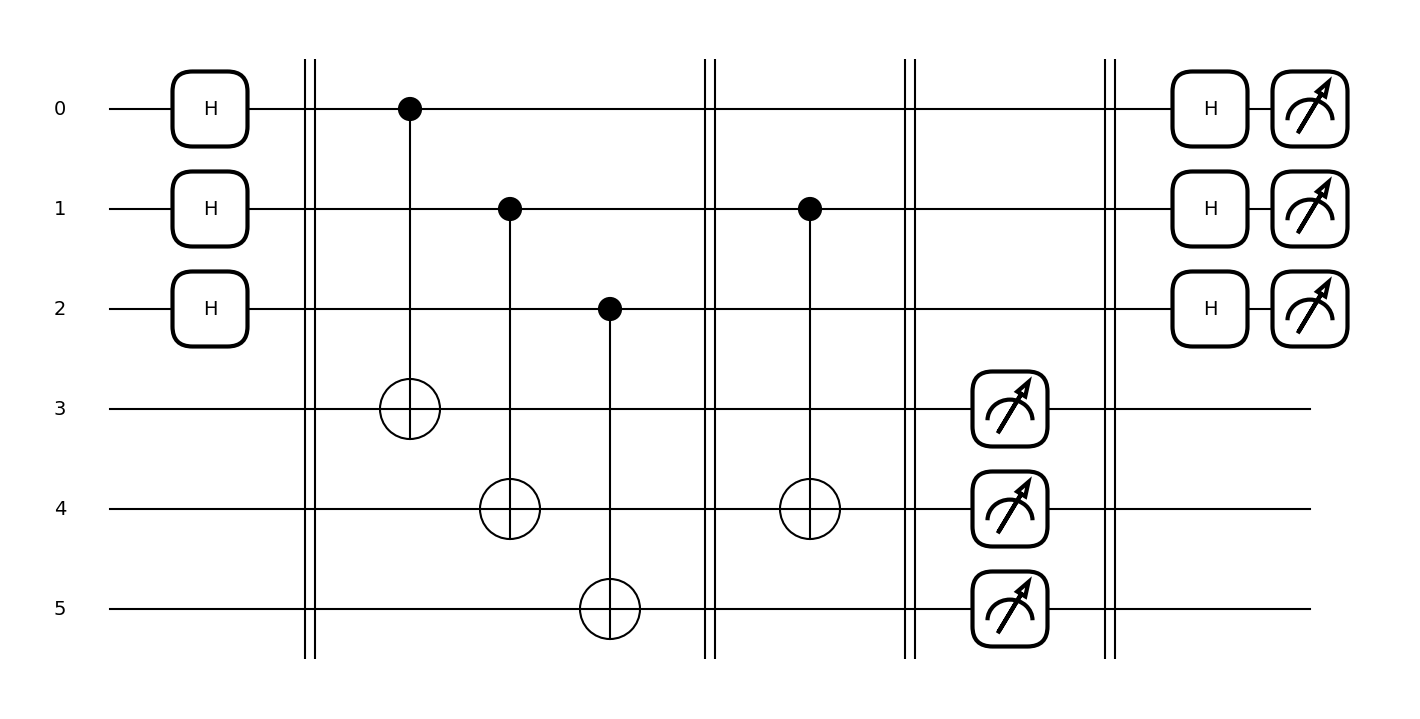

In [5]:
#plot da Imagem do Circuito
fig,ax =qml.draw_mpl(circuito_simon)()#desenho pra ver se ta certo

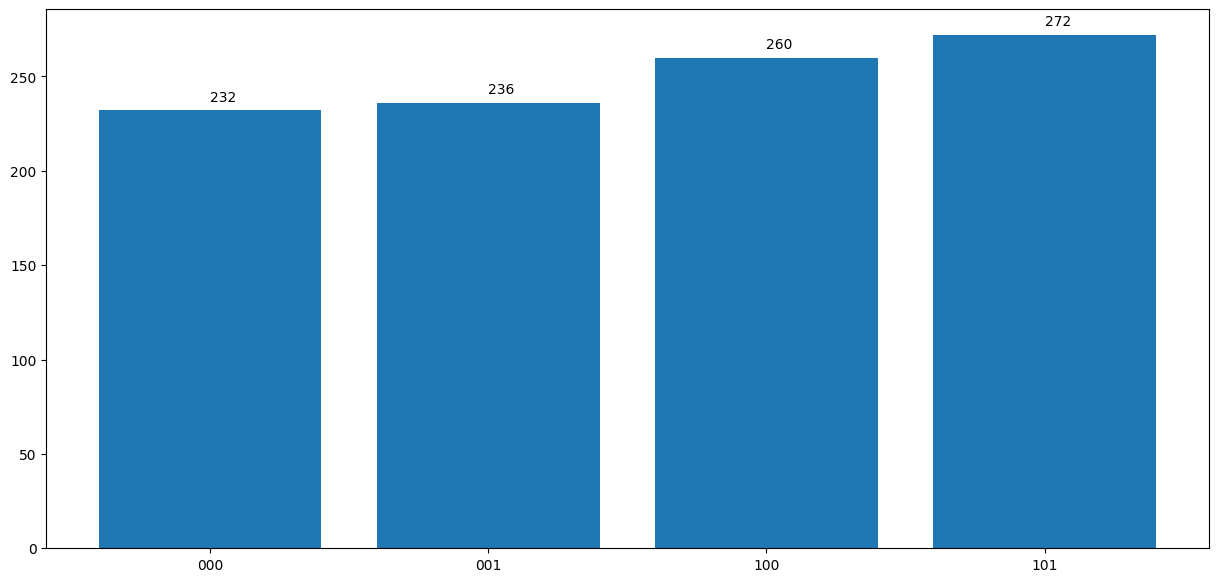

In [ ]:
#Guardar os resultados
resultados = circuito_simon()

#Plotar os gráficos
plt.figure(figsize=(15,7))
bits=list(resultados.keys())
freqs = list(resultados.values())

plt.bar(bits, freqs)
plt.xticks()
for i, f in enumerate(freqs):
    plt.text(i, f+5, str(f))
plt.tight_layout
plt.show()